### R-A Prediction Model ###

In [1]:
%matplotlib
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
ra_df= pd.read_csv("final_data.csv")
ra_df

,Unnamed: 0,PRS_std,age,sex,bmi,smoker,RA_STATUS
0,0,0.452651,55,0,28.3,0,1
1,1,2.144354,47,1,31.7,0,0
2,2,0.452220,18,0,29.1,0,0
3,3,-1.110793,51,1,26.4,1,1
4,4,-1.542000,59,1,32.9,0,0
...,...,...,...,...,...,...,...
2995,2995,-1.606766,59,1,32.7,0,0
2996,2996,-1.604685,46,1,28.8,0,0
2997,2997,0.974415,69,1,27.3,0,1
2998,2998,-0.080930,49,0,26.4,0,0


In [3]:
#profile=ProfileReport(ra_df,title="eda")

In [4]:
#profile 

In [5]:
ra_df["sex"].value_counts()

sex
1    2097
0     903
Name: count, dtype: int64

In [6]:
#profile.to_file("ra_data")

In [7]:
corr=ra_df.corr

In [8]:
corr()

,Unnamed: 0,PRS_std,age,sex,bmi,smoker,RA_STATUS
Unnamed: 0,1.000000,-0.018039,-0.003062,0.011339,0.027709,0.012157,0.007580
PRS_std,-0.018039,1.000000,0.018868,-0.011132,0.017977,0.021871,0.237264
age,-0.003062,0.018868,1.000000,-0.027515,0.109297,0.015972,0.117884
sex,0.011339,-0.011132,-0.027515,1.000000,0.007697,-0.095562,0.084358
bmi,0.027709,0.017977,0.109297,0.007697,1.000000,-0.014043,0.106388
smoker,0.012157,0.021871,0.015972,-0.095562,-0.014043,1.000000,0.158704
RA_STATUS,0.007580,0.237264,0.117884,0.084358,0.106388,0.158704,1.000000


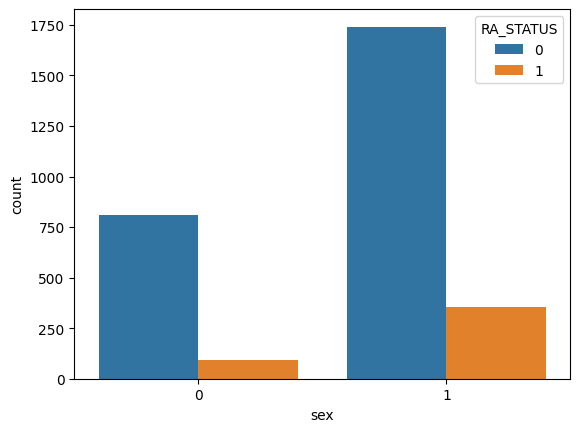

In [9]:
sns.countplot(x="sex",hue="RA_STATUS",data=ra_df)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

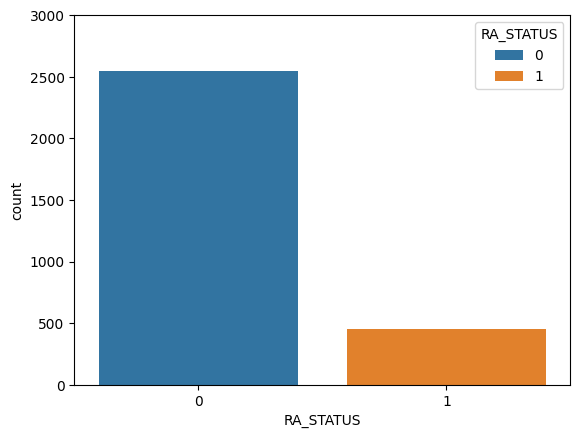

In [10]:
sns.countplot(x="RA_STATUS",hue="RA_STATUS",data=ra_df)
plt.ylim(0,3000)
plt.show 

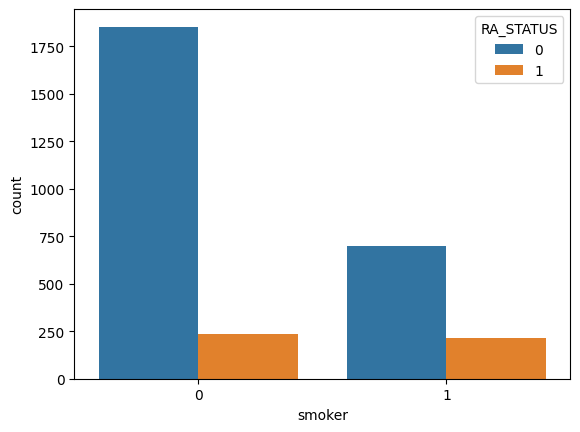

In [11]:
sns.countplot(x="smoker",hue="RA_STATUS",data=ra_df)
plt.show()

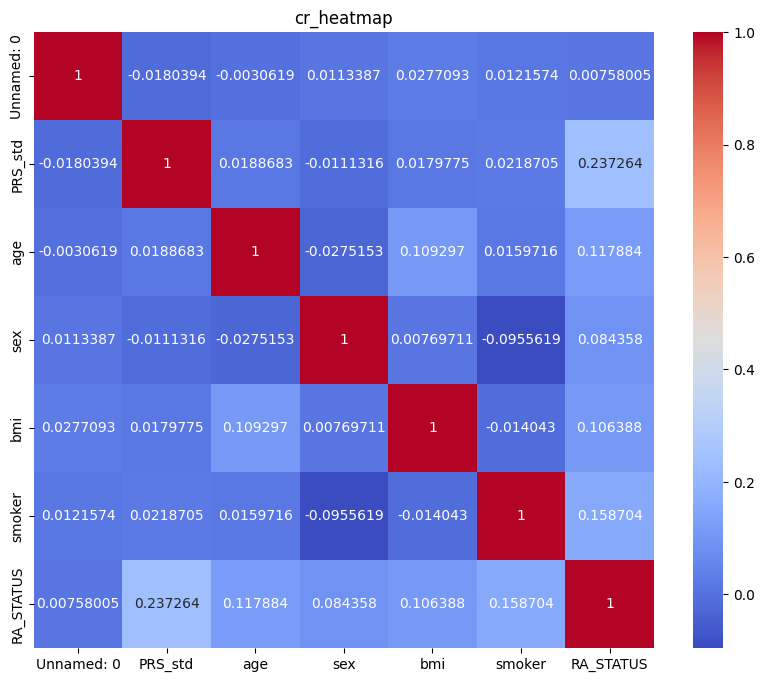

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(corr(),annot= True,cmap="coolwarm",fmt="g")
plt.title("cr_heatmap")
plt.show()

## Spliting of Data ##

In [13]:
from sklearn.model_selection import train_test_split

x=ra_df[["PRS_std","age","sex","bmi","smoker"]]
y=ra_df["RA_STATUS"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [14]:
x_train

,PRS_std,age,sex,bmi,smoker
642,0.475734,26,1,26.1,1
700,0.001070,43,1,32.5,0
226,-0.119436,70,1,21.8,0
1697,0.813672,71,0,27.0,0
1010,0.170062,52,1,35.2,1
...,...,...,...,...,...
1638,1.337827,61,1,26.0,1
1095,0.357765,43,1,26.2,0
1130,0.988141,38,0,27.6,1
1294,-1.600734,66,1,33.5,0


In [15]:
x_test

,PRS_std,age,sex,bmi,smoker
1801,0.128142,75,1,28.8,0
1190,-0.427241,48,1,21.8,0
1817,1.725280,53,1,26.6,0
251,-0.439885,71,0,25.8,0
2505,0.661921,70,1,30.9,0
...,...,...,...,...,...
104,-0.465028,66,0,31.2,0
2087,-0.120652,75,1,27.9,1
599,1.373048,72,1,24.3,0
1756,0.584921,39,1,24.6,0


In [16]:
ra_df["PRS_std"].max()

np.float64(3.174648935909072)

In [17]:
sel_col=["age","bmi"]

### Scaling ###

In [18]:
from sklearn.preprocessing import StandardScaler
sel_col=["age","bmi"]
scaler=StandardScaler()
x_train[sel_col]=scaler.fit_transform(x_train[sel_col])
x_test[sel_col]=scaler.transform(x_test[sel_col])

In [19]:
print(ra_df.dtypes)

Unnamed: 0      int64
PRS_std       float64
age             int64
sex             int64
bmi           float64
smoker          int64
RA_STATUS       int64
dtype: object


In [20]:
x_train

,PRS_std,age,sex,bmi,smoker
642,0.475734,-2.260919,1,-0.298354,1
700,0.001070,-0.889585,1,0.997882,0
226,-0.119436,1.288415,1,-1.169262,0
1697,0.813672,1.369082,0,-0.116070,0
1010,0.170062,-0.163585,1,1.544731,1
...,...,...,...,...,...
1638,1.337827,0.562415,1,-0.318607,1
1095,0.357765,-0.889585,1,-0.278100,0
1130,0.988141,-1.292919,0,0.005452,1
1294,-1.600734,0.965748,1,1.200418,0


In [21]:
x_train

,PRS_std,age,sex,bmi,smoker
642,0.475734,-2.260919,1,-0.298354,1
700,0.001070,-0.889585,1,0.997882,0
226,-0.119436,1.288415,1,-1.169262,0
1697,0.813672,1.369082,0,-0.116070,0
1010,0.170062,-0.163585,1,1.544731,1
...,...,...,...,...,...
1638,1.337827,0.562415,1,-0.318607,1
1095,0.357765,-0.889585,1,-0.278100,0
1130,0.988141,-1.292919,0,0.005452,1
1294,-1.600734,0.965748,1,1.200418,0


### Model Training ###

In [22]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
'''import pickle
with open ("lr_model.pkl", "wb") as f:
    pickle.dump(clf,f)'''

'import pickle\nwith open ("lr_model.pkl", "wb") as f:\n    pickle.dump(clf,f)'

In [24]:
y_pred=clf.predict(x_test)

In [25]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [26]:
pd.Series(y_pred).value_counts()

0    583
1     17
Name: count, dtype: int64

In [27]:
y_pred_prob=clf.predict_proba(x_test)[:,1]

In [28]:
y_pred_prob

array([0.17929246, 0.04441905, 0.27032448, 0.04900667, 0.24775307,
       0.05853651, 0.25756026, 0.01905696, 0.01818267, 0.11550696,
       0.08115226, 0.15230148, 0.18990017, 0.13085233, 0.1839213 ,
       0.19727343, 0.09538545, 0.09154684, 0.28609108, 0.05928466,
       0.19226512, 0.03321299, 0.04855053, 0.44333138, 0.05388838,
       0.01757917, 0.24072904, 0.20029361, 0.02277937, 0.40768764,
       0.03009844, 0.4140216 , 0.07134585, 0.02114439, 0.21378897,
       0.04278879, 0.01472411, 0.21764313, 0.32723519, 0.04252163,
       0.41470191, 0.00964687, 0.04377499, 0.36754836, 0.08612248,
       0.24296194, 0.15279604, 0.30546151, 0.52690102, 0.19972293,
       0.08708212, 0.05265773, 0.11932976, 0.17033117, 0.02106316,
       0.15973619, 0.03106244, 0.18364697, 0.12433343, 0.4224056 ,
       0.12880686, 0.38630083, 0.09179519, 0.05926902, 0.20359509,
       0.09989015, 0.04933051, 0.03427281, 0.65582905, 0.0552882 ,
       0.37429026, 0.47522767, 0.4373955 , 0.08751025, 0.21857

## Model Evaluation ##

In [29]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,classification_report,f1_score

In [30]:
print(accuracy_score(y_test,y_pred))

0.8566666666666667


In [31]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[501,   4],
       [ 82,  13]])

In [32]:
precision_score=precision_score(y_test,y_pred)
precision_score

0.7647058823529411

In [33]:
classification_report=classification_report(y_test,y_pred)
classification_report

'              precision    recall  f1-score   support\n\n           0       0.86      0.99      0.92       505\n           1       0.76      0.14      0.23        95\n\n    accuracy                           0.86       600\n   macro avg       0.81      0.56      0.58       600\nweighted avg       0.84      0.86      0.81       600\n'

In [34]:
print(classification_report)

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       505
           1       0.76      0.14      0.23        95

    accuracy                           0.86       600
   macro avg       0.81      0.56      0.58       600
weighted avg       0.84      0.86      0.81       600



In [35]:
from sklearn.metrics import roc_auc_score,roc_curve
auc=roc_auc_score(y_test,y_pred)
print("roc_auc_score:",roc_auc_score(y_test,y_pred_prob))

roc_auc_score: 0.7548097967691506


In [36]:
y.value_counts()

RA_STATUS
0    2550
1     450
Name: count, dtype: int64

## Balancing data ##

In [37]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_bal,y_train_bal=smote.fit_resample(x_train, y_train)
clf.fit(x_train_bal,y_train_bal)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
x_train_bal

,PRS_std,age,sex,bmi,smoker
0,0.475734,-2.260919,1,-0.298354,1
1,0.001070,-0.889585,1,0.997882,0
2,-0.119436,1.288415,1,-1.169262,0
3,0.813672,1.369082,0,-0.116070,0
4,0.170062,-0.163585,1,1.544731,1
...,...,...,...,...,...
4085,0.789755,1.833339,1,1.064490,0
4086,0.790714,0.150846,1,1.221636,0
4087,0.469443,-0.239414,1,-0.275671,1
4088,1.010088,-1.783680,1,-0.709801,0


In [39]:
y_train_bal.value_counts()

RA_STATUS
1    2045
0    2045
Name: count, dtype: int64

## Model Evaluation ##

In [40]:
y1_pred=clf.predict(x_test)

In [41]:
y1_pred

array([1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,

In [42]:
cm_2=confusion_matrix(y1_pred,y_test)
cm_2

array([[343,  26],
       [162,  69]])

In [43]:
y1_pred_prob=clf.predict_proba(x_test)[:,1]
y1_pred_prob

array([0.57762458, 0.19866375, 0.69769746, 0.23332774, 0.67907733,
       0.26746675, 0.66944881, 0.08885327, 0.08706595, 0.39739252,
       0.34077601, 0.53605103, 0.5390947 , 0.4698655 , 0.58114105,
       0.59194663, 0.34391448, 0.36215874, 0.69201929, 0.26442004,
       0.60281227, 0.15592619, 0.18922991, 0.81710213, 0.24569072,
       0.083548  , 0.62732535, 0.55320313, 0.11290879, 0.78455086,
       0.14416498, 0.80764639, 0.30704906, 0.09943803, 0.62626435,
       0.20350589, 0.0586291 , 0.63447623, 0.73208477, 0.20563096,
       0.80024507, 0.04857586, 0.19925382, 0.7990887 , 0.3596003 ,
       0.68483814, 0.54035161, 0.69286973, 0.86034234, 0.62920471,
       0.35581245, 0.22592367, 0.44670351, 0.55735921, 0.09896804,
       0.54670229, 0.15070479, 0.58109183, 0.42732841, 0.82777791,
       0.46240113, 0.78473198, 0.37089069, 0.25639344, 0.55672934,
       0.39255125, 0.23674563, 0.15917505, 0.9207657 , 0.24595889,
       0.76339019, 0.83477034, 0.8130579 , 0.34807773, 0.62990

In [44]:
pd.Series(y1_pred).value_counts()

0    369
1    231
Name: count, dtype: int64

In [45]:
print("ROC AUC:", roc_auc_score(y_test,y1_pred_prob))

ROC AUC: 0.7599999999999999


<function matplotlib.pyplot.show(close=None, block=None)>

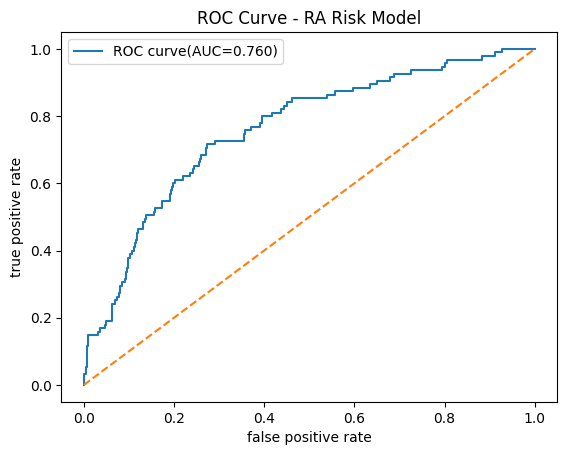

In [46]:
from sklearn.metrics import roc_curve, auc
fpr,tpr,thresholds = roc_curve(y_test,y1_pred_prob)
roc_auc= auc(fpr,tpr)
plt.figure()
plt.plot(fpr,tpr,label="ROC curve(AUC=%0.3f)" % roc_auc)
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC Curve - RA Risk Model")
plt.legend()
plt.show

## Shap analysis

In [47]:
import shap 
explainer = shap.LinearExplainer(clf,x_train)
shap_values=explainer.shap_values(x_test)

In [48]:
shap_values

array([[ 0.15043731,  0.64265105,  0.19394909,  0.1247381 , -0.2557376 ],
       [-0.30339992, -0.13197298,  0.19394909, -0.35449719, -0.2557376 ],
       [ 1.45555689,  0.01147591,  0.19394909, -0.02587871, -0.2557376 ],
       ...,
       [ 1.16772674,  0.55658171,  0.19394909, -0.18334173, -0.2557376 ],
       [ 0.52369936, -0.39018099,  0.19394909, -0.16280308, -0.2557376 ],
       [ 0.80791647, -0.73445834, -0.52438087, -0.21757282, -0.2557376 ]],
      shape=(600, 5))

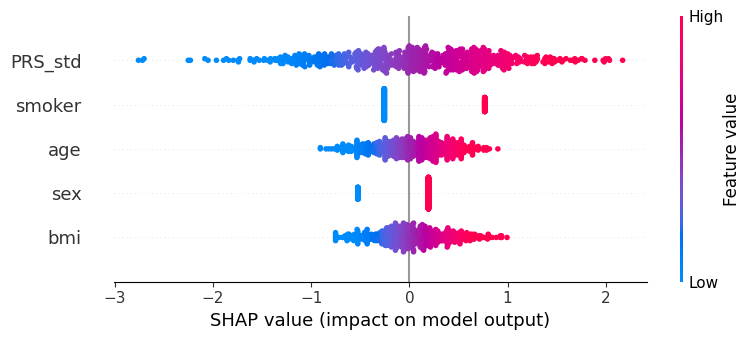

In [49]:
shap.summary_plot(shap_values, x_test,feature_names=x.columns.tolist())

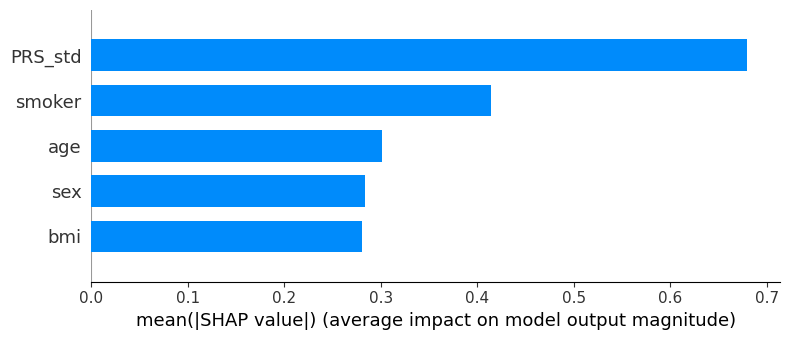

In [50]:
shap.summary_plot(shap_values, x_test,feature_names=x.columns.tolist(),plot_type="bar")

In [51]:
import sys 
print(sys.executable)

D:\conda\envs\bioinfo\python.exe


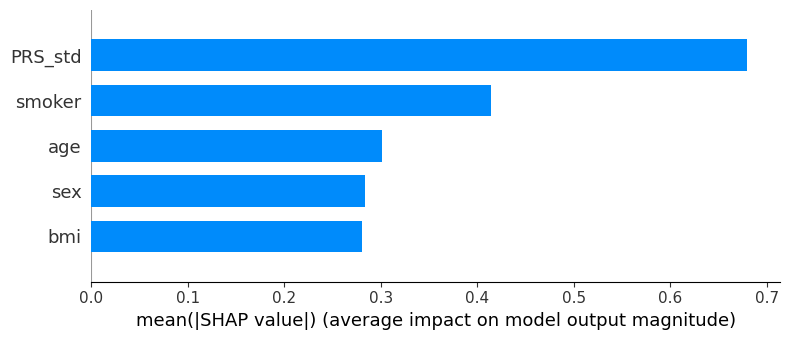

In [52]:
shap.summary_plot(shap_values, x_test,feature_names=x.columns.tolist(),plot_type="bar")

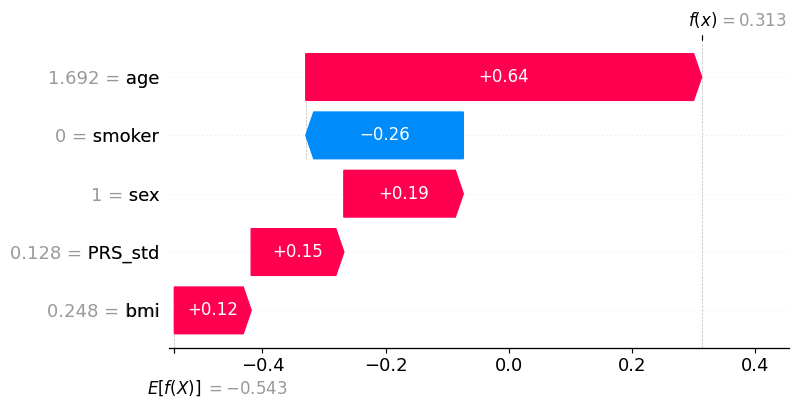

In [53]:
shap.waterfall_plot(shap.Explanation(values=shap_values[0],base_values=explainer.expected_value,data=x_test.iloc[0],feature_names=x.columns.tolist()))

## Gradientboost_Model

In [77]:
from sklearn.ensemble import GradientBoostingClassifier
gbm=GradientBoostingClassifier(random_state=42)
gbm.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [55]:
y_gbm=gbm.predict(x_test)
y_gbm

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [56]:
y2_prob=gbm.predict_proba(x_test)[:,1]
y2_prob

array([0.09762772, 0.0482374 , 0.11004609, 0.07505139, 0.15828451,
       0.06891665, 0.07039512, 0.03387505, 0.03941515, 0.14326698,
       0.1159471 , 0.09807065, 0.10453664, 0.09846258, 0.11420735,
       0.07816407, 0.07489621, 0.11031942, 0.26968949, 0.07163052,
       0.20637967, 0.07166851, 0.03918894, 0.50073321, 0.03700052,
       0.03522404, 0.2585237 , 0.3919483 , 0.03367339, 0.32416822,
       0.18351638, 0.28022097, 0.06098469, 0.06984074, 0.17341381,
       0.03827949, 0.03721461, 0.16451761, 0.29743173, 0.08489524,
       0.41842009, 0.0300786 , 0.07140306, 0.23374734, 0.07198419,
       0.34793928, 0.17149752, 0.31349648, 0.38498837, 0.10939466,
       0.07811457, 0.11439715, 0.0898928 , 0.11917895, 0.02983365,
       0.07766117, 0.0756311 , 0.12357777, 0.13038886, 0.41005994,
       0.11679847, 0.45661607, 0.09300531, 0.05917343, 0.26814585,
       0.06875613, 0.08248326, 0.03977883, 0.29139845, 0.04594053,
       0.40550173, 0.51301107, 0.63438363, 0.08501741, 0.09424

In [57]:
print("gbm ROC AUC:",roc_auc_score(y_test,y2_prob))

gbm ROC AUC: 0.7215216258467952


In [58]:
print(accuracy_score(y_test,y_gbm))

0.8433333333333334


In [59]:
'''with  open ("Gradient_Boosting.pkl","wb") as f:
    pickle.dump(gbm,f)'''

'with  open ("Gradient_Boosting.pkl","wb") as f:\n    pickle.dump(gbm,f)'

In [60]:
from sklearn.model_selection import GridSearchCV

param_grid= {'max_depth': [3,4,5],'learning_rate':[0.01,0.1],'n_estimators':[100,200]}
gbm= GradientBoostingClassifier(random_state=42)
grid= GridSearchCV(estimator=gbm,param_grid=param_grid,scoring='roc_auc',cv=3,verbose=1)
grid.fit(x_train,y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [61]:
print("best params",grid.best_params_)
print("Best Auc:",grid.best_score_)

best params {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best Auc: 0.7406844875867039


In [62]:
gbm_1=GradientBoostingClassifier(learning_rate=0.01,max_depth=3,n_estimators=200)
gbm_1.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.01
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [63]:
pred=gbm_1.predict(x_test)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [64]:
pred_pro=gbm_1.predict_proba(x_test)[:,1]

In [65]:
print(accuracy_score(y_test,pred))

0.8433333333333334


In [66]:
pred_pro

array([0.10368708, 0.06556087, 0.15923745, 0.09742303, 0.13521194,
       0.09412522, 0.18752464, 0.0670194 , 0.0742939 , 0.21249355,
       0.12762544, 0.15289998, 0.11009403, 0.1022741 , 0.11526883,
       0.13484015, 0.10044089, 0.11582305, 0.30646211, 0.10899596,
       0.2667469 , 0.08309159, 0.0703706 , 0.44077146, 0.09357258,
       0.0742939 , 0.21471115, 0.25000862, 0.06317805, 0.32162986,
       0.08445265, 0.28145478, 0.08103536, 0.0670194 , 0.20022409,
       0.07138518, 0.08523577, 0.15844942, 0.36632559, 0.09742303,
       0.33150722, 0.09937101, 0.07039226, 0.25106525, 0.09881103,
       0.26751032, 0.17933824, 0.28471555, 0.33543551, 0.17634429,
       0.08725037, 0.1022741 , 0.09041923, 0.13653807, 0.0631863 ,
       0.12989945, 0.12204413, 0.13136775, 0.11547535, 0.34797138,
       0.12387207, 0.35997634, 0.08860557, 0.07705157, 0.28262272,
       0.07705157, 0.09414007, 0.10899596, 0.49445345, 0.08502806,
       0.30565457, 0.47253208, 0.43936347, 0.10090942, 0.15923

In [67]:
print("ruc_auc_gbm_1:",roc_auc_score(y_test,pred_pro))

ruc_auc_gbm_1: 0.7141532047941637


### XGBOOST_Model ###

In [68]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold

param_dist={'n_estimators':[100,200,300,500],'max_depth':[3,4,5,6],'learning_rate':[0.01,0.05,0.1,0.2],'min_child_weight':[1,3,5],'gamma':[0,0.1,0.2]}
xgb=XGBClassifier(scale_pos_weight=6,eval_metric='auc',random_state=42)
cv=StratifiedKFold(n_splits=5,shuffle=True, random_state=42)
search=RandomizedSearchCV(xgb,param_distributions=param_dist,n_iter=50,scoring='roc_auc',cv=cv,random_state=42,n_jobs=-1,verbose=1)
search.fit(x_train,y_train)
print("best params:",search.best_params_)
print("best cv:",search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best params: {'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0}
best cv: 0.7399325045628293


In [69]:
xgb_1=XGBClassifier(n_estimators=300,min_child_weight=3,max_depth=3,learning_rate=0.01,gamma=0,scale_pos_weight=6)
xgb_1.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [70]:
'''with open ("XGBClassifier.pkl","wb")as f:
    pickle.dump(xgb_1,f)'''

'with open ("XGBClassifier.pkl","wb")as f:\n    pickle.dump(xgb_1,f)'

In [71]:
predxg=xgb_1.predict(x_test)

In [72]:
predxg

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,

In [73]:
xgb_prob=xgb_1.predict_proba(x_test)[:,1]

In [74]:
xgb_prob

array([0.4353836 , 0.23660193, 0.5343898 , 0.39372483, 0.57528704,
       0.3608872 , 0.5254237 , 0.22694162, 0.23546264, 0.56259507,
       0.41492063, 0.5437451 , 0.45178965, 0.40259624, 0.44235575,
       0.4834906 , 0.37637702, 0.4374376 , 0.66955173, 0.37160742,
       0.67122823, 0.25153622, 0.19676211, 0.8072218 , 0.27890623,
       0.2478581 , 0.6026703 , 0.67930007, 0.13438767, 0.7719407 ,
       0.3730348 , 0.7132299 , 0.2247462 , 0.19233428, 0.62478703,
       0.24658982, 0.20172107, 0.533596  , 0.7433725 , 0.39372483,
       0.76047665, 0.18043514, 0.21165861, 0.6573664 , 0.27185464,
       0.67532885, 0.53269506, 0.7157848 , 0.7406822 , 0.5707959 ,
       0.3140295 , 0.39607885, 0.37348902, 0.46092033, 0.19476096,
       0.42731   , 0.21618682, 0.517912  , 0.44640163, 0.7136119 ,
       0.43208072, 0.7268404 , 0.3608529 , 0.29927316, 0.7143385 ,
       0.3223991 , 0.39248115, 0.34915018, 0.7523059 , 0.23542283,
       0.7237159 , 0.81175405, 0.8027149 , 0.37927914, 0.54771

In [75]:
print("roc_auc_score:",roc_auc_score(y_test,xgb_prob))

roc_auc_score: 0.7299843668577384


### Model_Comparison ###

In [78]:
models= {"Logistic Regression":clf,"Gradient Boosting":gbm,"XGBossting":xgb_1}
print("="*40)
print(f"{'Model':<25}{'AUC':>10}")
print("=" * 40)
for name, model in models.items():
    y_prob= model.predict_proba(x_test)[:,1]
    auc= roc_auc_score(y_test,y_prob)
    print(f"{name:<25} {auc:>10.3f}")
print("=" * 40)

Model                           AUC
Logistic Regression            0.760
Gradient Boosting              0.722
XGBossting                     0.730


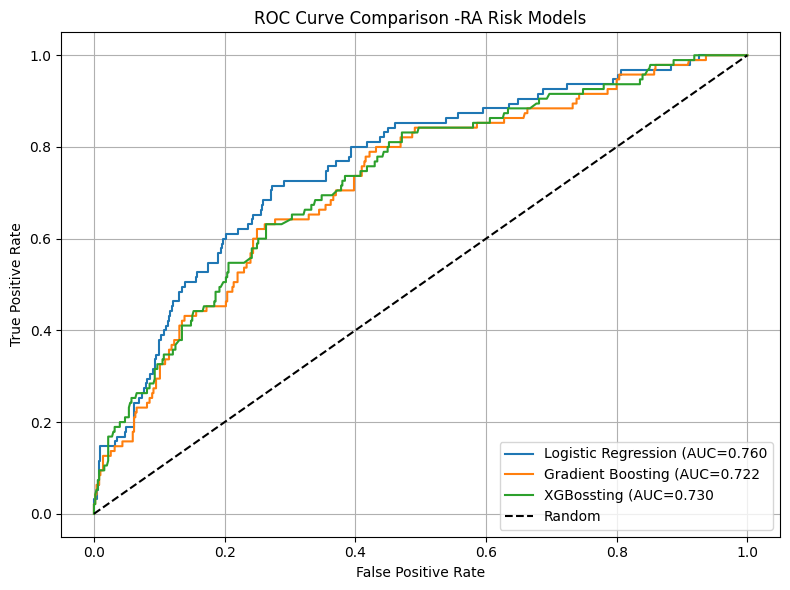

In [79]:
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob=model.predict_proba(x_test)[:,1]
    fpr,tpr,_= roc_curve(y_test,y_prob)
    auc = roc_auc_score(y_test,y_prob)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f}")
plt.plot([0,1],[0,1],'k--',label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison -RA Risk Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_comaprision.png",dpi=150)
plt.show()

In [80]:
import shap 
explainer = shap.LinearExplainer(clf,x_train)
shap_values=explainer.shap_values(x_test)
shap_values

array([[ 0.15043731,  0.64265105,  0.19394909,  0.1247381 , -0.2557376 ],
       [-0.30339992, -0.13197298,  0.19394909, -0.35449719, -0.2557376 ],
       [ 1.45555689,  0.01147591,  0.19394909, -0.02587871, -0.2557376 ],
       ...,
       [ 1.16772674,  0.55658171,  0.19394909, -0.18334173, -0.2557376 ],
       [ 0.52369936, -0.39018099,  0.19394909, -0.16280308, -0.2557376 ],
       [ 0.80791647, -0.73445834, -0.52438087, -0.21757282, -0.2557376 ]],
      shape=(600, 5))

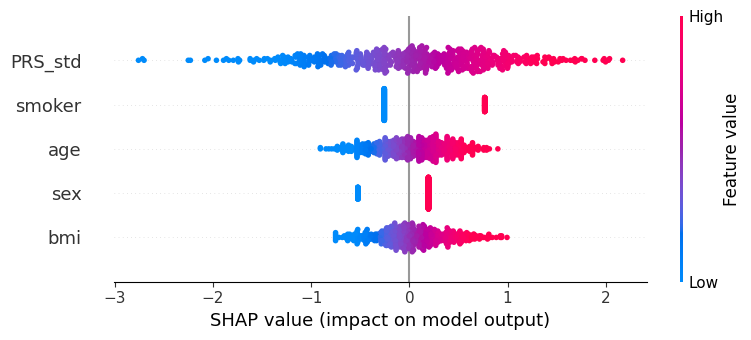

In [81]:
shap.summary_plot(shap_values, x_test,feature_names=x.columns.tolist())

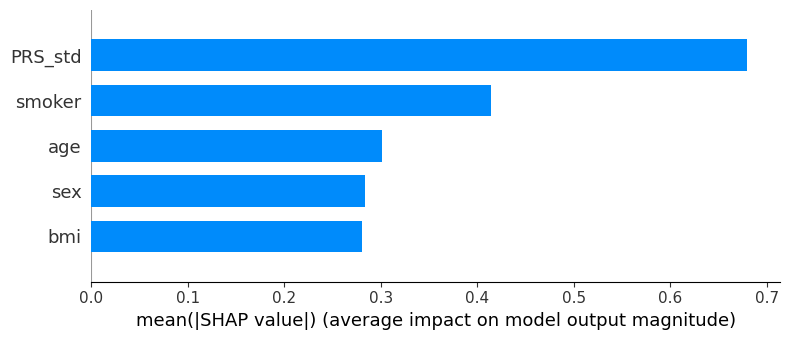

In [82]:
shap.summary_plot(shap_values, x_test,feature_names=x.columns.tolist(),plot_type="bar")

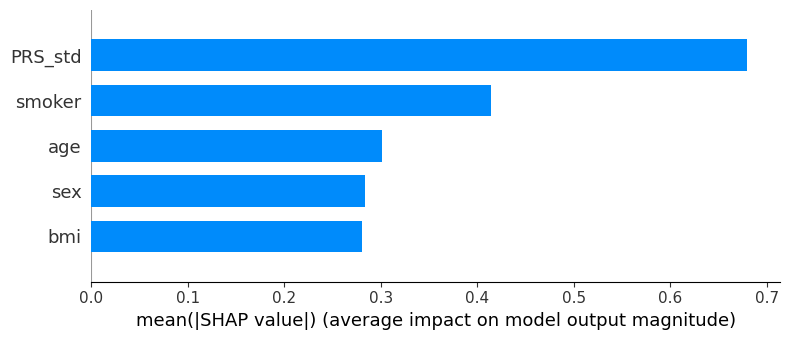

In [83]:
shap.summary_plot(shap_values, x_test,feature_names=x.columns.tolist(),plot_type="bar")

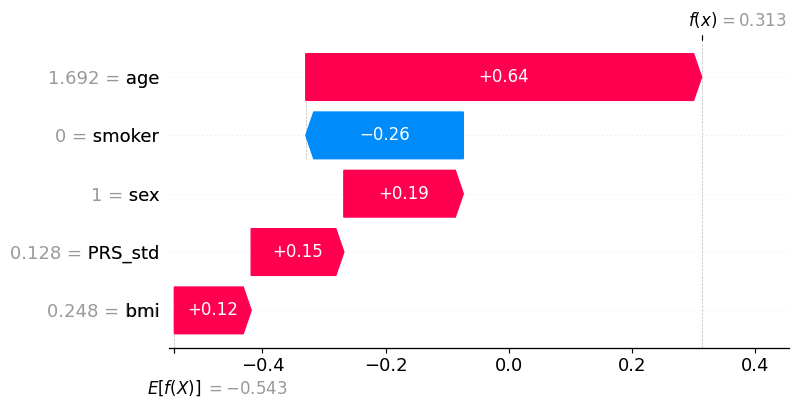

In [84]:
shap.waterfall_plot(shap.Explanation(values=shap_values[0],base_values=explainer.expected_value,data=x_test.iloc[0],feature_names=x.columns.tolist()))

In [85]:
import shap
shap.initjs()

In [86]:
shap.force_plot(explainer.expected_value,shap_values,x_test,feature_names=x.columns.tolist())

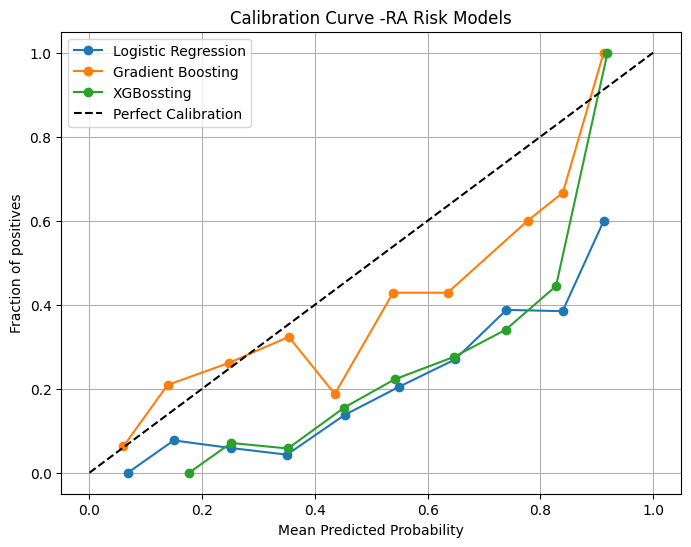

In [87]:
from sklearn.calibration import calibration_curve
plt.figure(figsize=(8,6))
for name,model in models.items():
    y_prob=model.predict_proba(x_test)[:,1]
    fraction_pos,mean_pred=calibration_curve(y_test,y_prob,n_bins=10)
    plt.plot(mean_pred,fraction_pos,marker="o",label=name)
plt.plot([0,1],[0,1],'k--',label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve -RA Risk Models")
plt.legend()
plt.grid(True)
plt.show()

In [88]:
from sklearn.calibration import CalibratedClassifierCV , calibration_curve

clf_calibrated = CalibratedClassifierCV( clf,cv=5,method='isotonic')
clf_calibrated.fit(x_train,y_train)

,estimator,LogisticRegression()
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [90]:
l2_pred=clf_calibrated.predict(x_test)

In [91]:
l3_prob=clf_calibrated.predict_proba(x_test)[:,1]

In [92]:
print("roc_auc_score:",roc_auc_score(y_test,l3_prob))

roc_auc_score: 0.7545075560187597


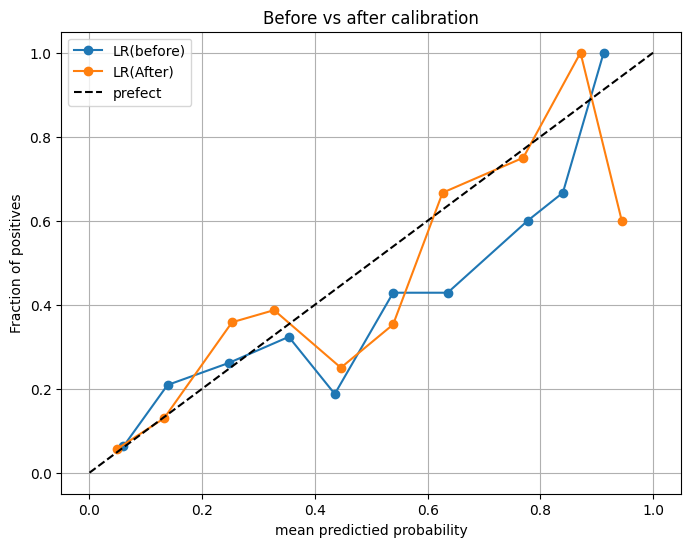

In [93]:
plt.figure(figsize=(8,6))
y_prob_before=gbm.predict_proba(x_test)[:,1]
frac_pos,mean_pred=calibration_curve(y_test,y_prob_before,n_bins=10)
plt.plot(mean_pred,frac_pos,marker='o',label="LR(before)")
y_proba_after=l3_prob
frac_pos_cal,mean_pred_cal=calibration_curve(y_test,y_proba_after,n_bins=10)
plt.plot(mean_pred_cal,frac_pos_cal,marker='o',label="LR(After)")
plt.plot([0,1],[0,1],'k--',label="prefect")
plt.xlabel("mean predictied probability")
plt.ylabel("Fraction of positives")
plt.title("Before vs after calibration")
plt.legend()
plt.grid(True)
plt.show()

In [94]:
pd.Series(l2_pred).value_counts()

0    570
1     30
Name: count, dtype: int64

In [ ]:
#pd.DataFrame(x_test).to_csv("data_x_test_csv",index=False)

In [ ]:
#pd.Series(y_test).to_csv("data_y_test_csv",index=False)

In [96]:
import pickle 
with open("ra_scaler.pkl", "wb") as f:
    pickle.dump(scaler,f)